# Project 3 - Data Visualization with NHTS

In [2]:
# We will first begin by importing our packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This will allow for a clean visual style
sns.set_style('whitegrid')
sns.set_palette('deep')

In [3]:
#### Load in the data in csv

 # importing the national household travel survey
nhts_data = pd.read_csv('NHTS.csv')
# Perform the previously learned techniques to visualize the head, tail, columns, and print the data 
# Load the NGSIM dataset
ngsim_data = pd.read_csv('NGSIM.csv')

# Task one: Create Visualizations of Important Features and Trends in Data

## Bar Chart
  #### Vehicle Make by Census Division

<Figure size 2000x1000 with 0 Axes>

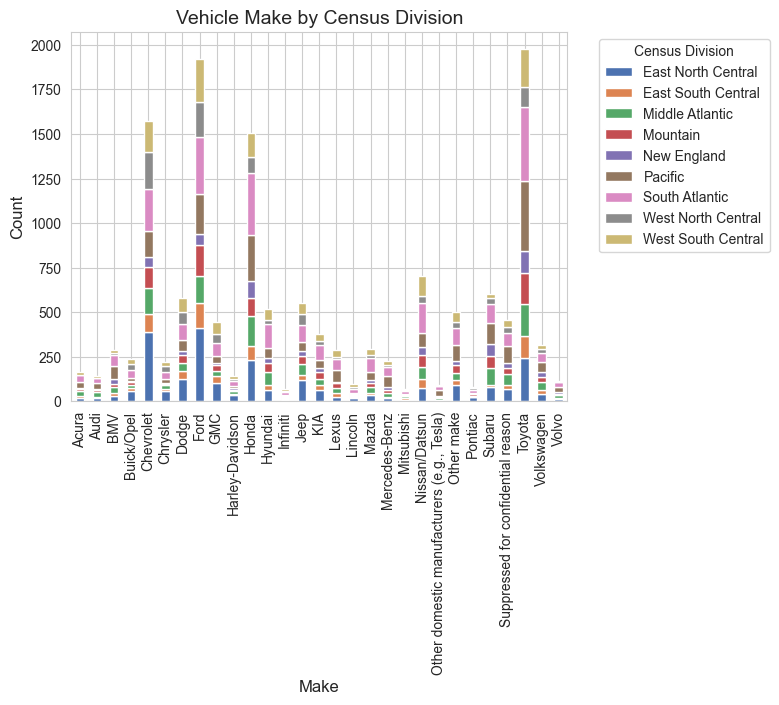

In [4]:
# We will begin our bar chart by filtering out NA values, and grouping the data by 'make' and 'census_division'

nhts_data = nhts_data.dropna(subset = ['make'])

data_grouped = nhts_data.groupby(['make', 'census_division']).size().unstack(fill_value = 0)

# Plotting
plt.figure(figsize = (20,10))
data_grouped.plot( kind = 'bar', stacked = True)

# Customizing the plot
plt.xlabel ('Make', fontsize = 12)
plt.ylabel('Count', fontsize = 12)
plt.title('Vehicle Make by Census Division', fontsize = 14)

# Making the legend more organized
plt.legend(title = 'Census Division', bbox_to_anchor = (1.05, 1), loc = 'upper left')


#Show the plot
plt.show()

## Histograms
  #### Average Vehicles per Household by Census Region (right side)
  #### Distribution of Vehicle Types: Urban vs. Rural (left side)

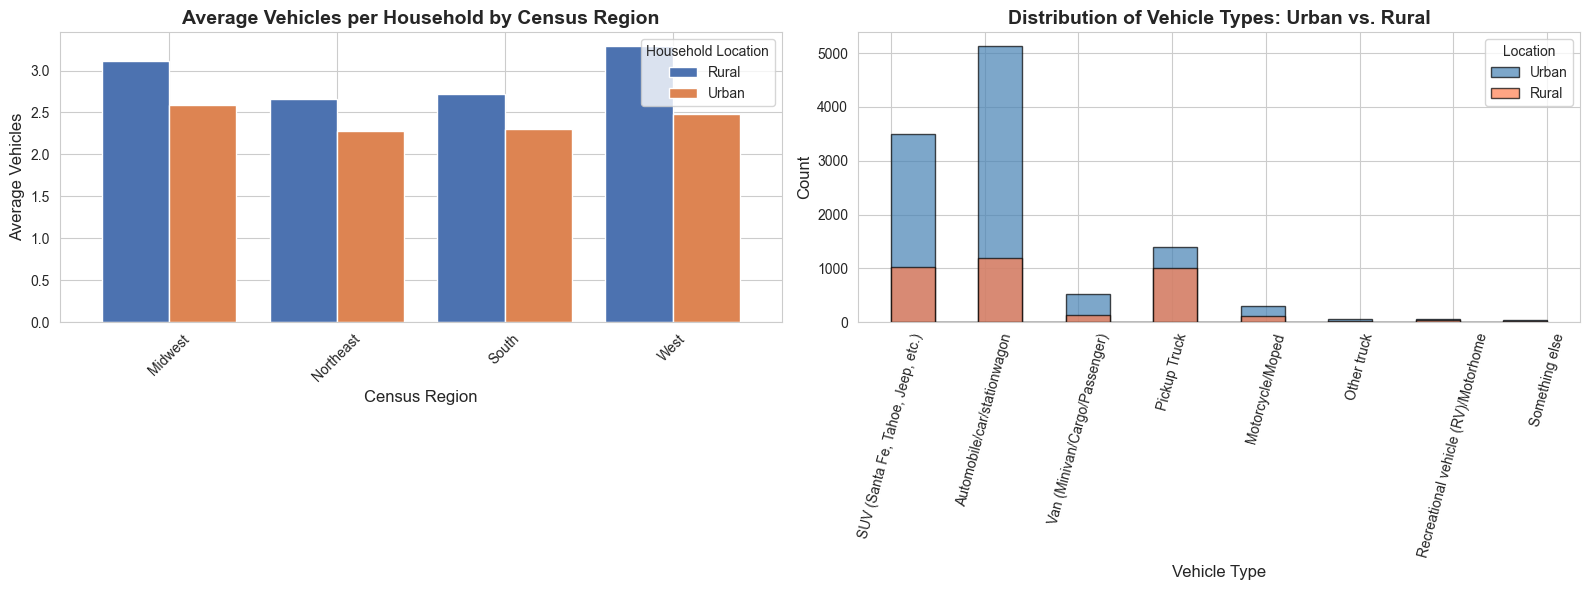

In [5]:
# Here we will be making two histograms side by side

# Setting up the figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# PLOT 1 (Left side): Grouped Bar Chart - Average Vehicles by Region & Location
# Step 1: Group the data, calculate the mean, and unstack
grouped_data = nhts_data.groupby(['census_region', 'household_location'])['vehicles_per_household'].mean().unstack()

# Step 2: Plot as a grouped bar chart on the first axis (axes[0])
grouped_data.plot(kind='bar', ax=axes[0], width=0.8)

# Step 3: Add labels, title, and legend
axes[0].set_title('Average Vehicles per Household by Census Region', fontsize=14, weight='bold')
axes[0].set_xlabel('Census Region', fontsize=12)
axes[0].set_ylabel('Average Vehicles', fontsize=12)
axes[0].tick_params(axis='x', rotation=45) # Rotate the x-axis labels so they fit
axes[0].legend(title='Household Location')



# PLOT 2 (Right side): Overlapping Histogram - Vehicle Ages Urban vs. Rural
# Step 1: Filter the data for Urban and Rural
urban_ages = nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_type']
rural_ages = nhts_data[nhts_data['household_location'] == 'Rural']['vehicle_type']

# Step 2: Plot the histograms on the second axis (axes[1])
axes[1].hist(urban_ages, bins=15, edgecolor='black', alpha=0.7, color='steelblue', label='Urban')
axes[1].hist(rural_ages, bins=15, edgecolor='black', alpha=0.7, color='coral', label='Rural')
plt.xticks(rotation = 75)
# Step 3: Add labels, title, and legend
axes[1].set_title('Distribution of Vehicle Types: Urban vs. Rural', fontsize=14, weight='bold')
axes[1].set_xlabel('Vehicle Type', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].legend(title='Location')

plt.tight_layout()
plt.show()


## Boxplot
  #### Vehicle Age by Make

<Figure size 1400x600 with 0 Axes>

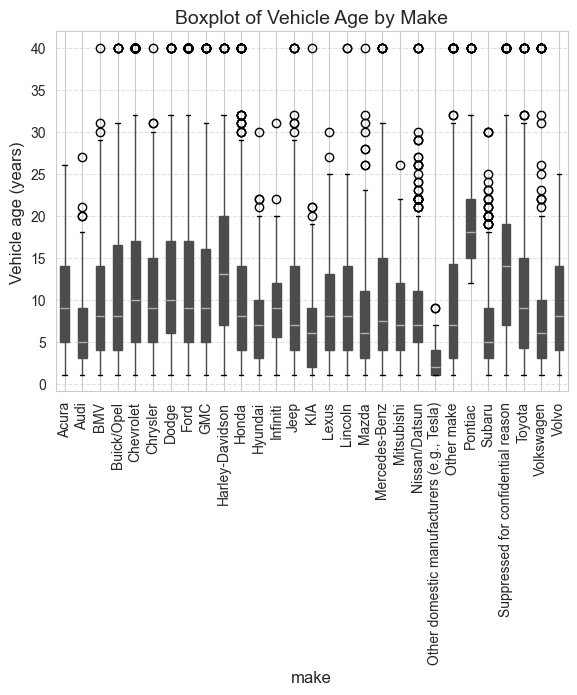

In [6]:


## Telling python we are making a figure and what size it will be
plt.figure(figsize = (14,6))


## Telling what variables we want to plot
boxplot = nhts_data.boxplot( column = 'vehicle_age', by = 'make', patch_artist = True)


## Rotating our x-axis by 90 so it is easier to read
plt.xticks(rotation = 90)


### Customizations
plt.xlabel ('make', fontsize = 12)
plt.ylabel('Vehicle age (years)', fontsize = 12)

# Removing the automatic pandas title
plt.suptitle('')
plt.title('Boxplot of Vehicle Age by Make', fontsize = 14)

# Adding a grid
plt.grid(axis = 'y', linestyle = '--', alpha = 0.6)

plt.show()

## Time Series Plots
  #### Position vs Time (upper left)
  #### Speed vs Time (upper right)
  #### Acceleration vs Time (bottom left)
  #### Gap Distance vs Time (bottom right)

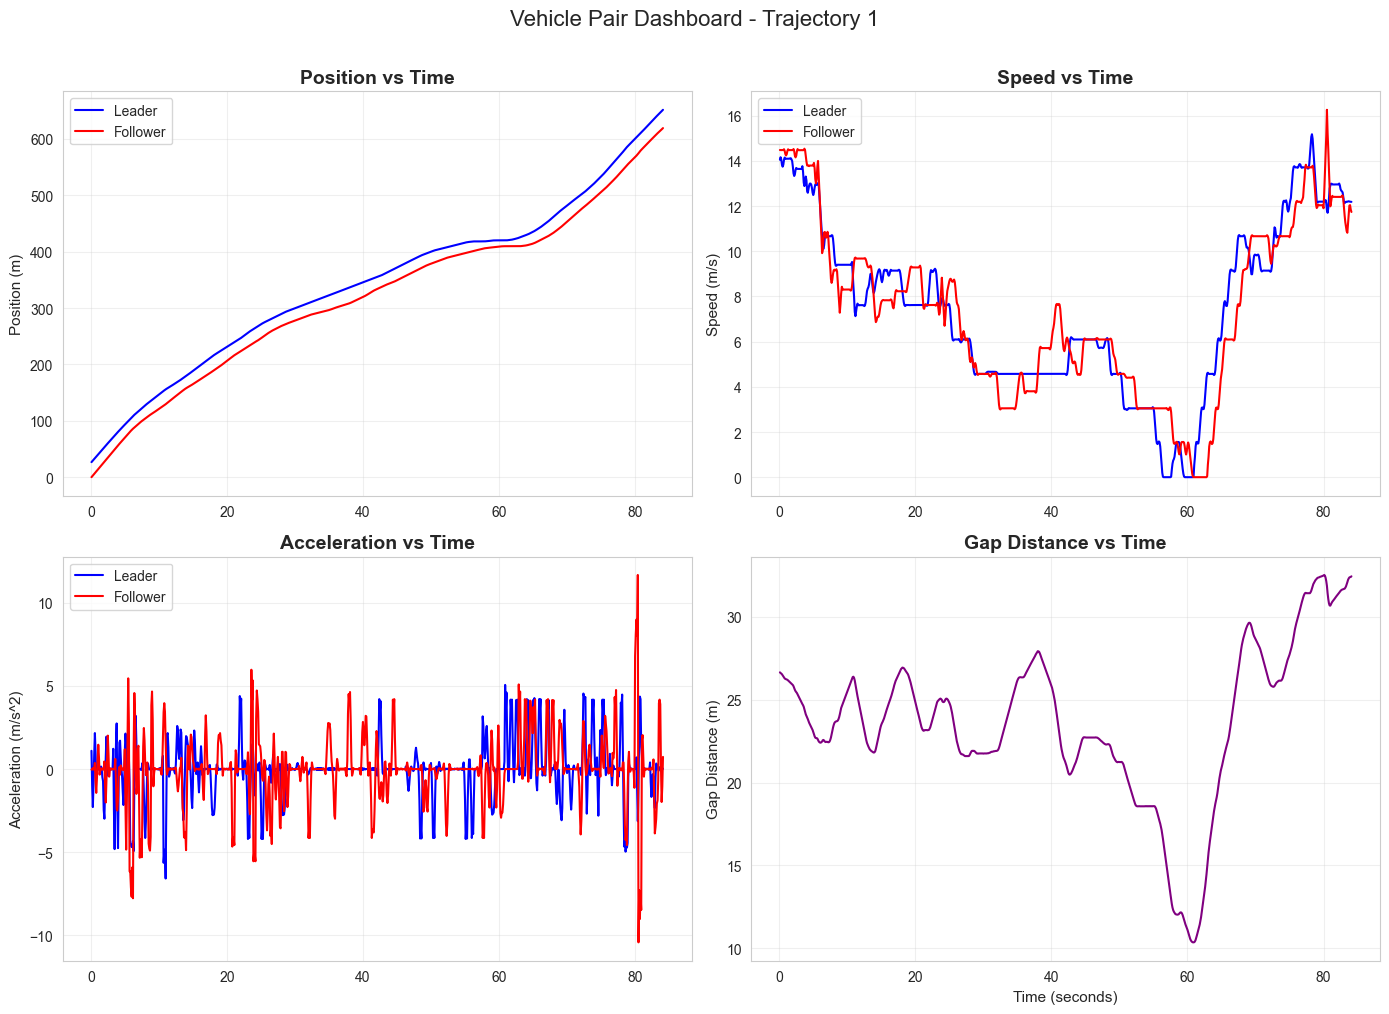

In [7]:
# Create a 2x2 subplot figure showing: trajectory, speed, acceleration, and gap for one vehicle pair

# Select a trajectory number and create the subset
trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]
gap = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values
time = data_subset['Time'].values

# Create the figure with 2 rows and 2 columns
fix, axes = plt.subplots(2,2, figsize = (14,10))

# Position vs Time for both leader and follower
axes[0,0].plot(time, data_subset['leader_position(m)'].values, 'b-', label = 'Leader', linewidth=1.5)
axes[0,0].plot(time, data_subset['follower_position(m)'].values, 'r-', label = 'Follower', linewidth=1.5)
axes[0,0].set_ylabel('Position (m)', fontsize = 11)
axes[0,0].set_title('Position vs Time', fontsize = 14, weight = 'bold')
axes[0,0].legend(fontsize = 10)
axes[0,0].grid(True, alpha=0.3)

# Speed vs Time for both leader and follower
axes[0,1].plot(time, data_subset['leader_speed(m/s)'].values, 'b-', label = 'Leader', linewidth=1.5)
axes[0,1].plot(time, data_subset['follower_speed(m/s)'].values, 'r-', label = 'Follower', linewidth=1.5)
axes[0,1].set_ylabel('Speed (m/s)', fontsize = 11)
axes[0,1].set_title('Speed vs Time', fontsize = 14, weight = 'bold')
axes[0,1].legend(fontsize = 10)
axes[0,1].grid(True, alpha=0.3)

# Acceleration vs Time for both leader and follower
axes[1,0].plot(time, data_subset['leader_acc(m/s^2)'].values, 'b-', label = 'Leader', linewidth=1.5)
axes[1,0].plot(time, data_subset['follower_acc(m/s^2)'].values, 'r-', label = 'Follower', linewidth=1.5)
axes[1,0].set_ylabel('Acceleration (m/s^2)', fontsize = 11)
axes[1,0].set_title('Acceleration vs Time', fontsize = 14, weight = 'bold')
axes[1,0].legend(fontsize = 10)
axes[1,0].grid(True, alpha=0.3)

# Gap Distance vs Time
axes[1,1].plot(time, gap, 'purple', linewidth=1.5)
axes[1,1].set_xlabel('Time (seconds)', fontsize = 11)
axes[1,1].set_ylabel('Gap Distance (m)', fontsize = 11)
axes[1,1].set_title('Gap Distance vs Time', fontsize = 14, weight = 'bold')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'Vehicle Pair Dashboard - Trajectory {trajectory_number}', fontsize = 16, y =1.01)
plt.tight_layout()
plt.show()

# Task Two: Provide a Simulation Study Using the Intelligent Driver Model (IDM)

### Define the IDM Acceleration Function

In [8]:
# Define the IDM acceleration function
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    #Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
    # Makes sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0) ** delta - (s_star/s)**2)
    
    
    
    return acceleration

### Selecting a Trajectory Pair

In [9]:
# Load the NGSIM data to get the leader vehicle trajectory
ngsim_data = pd.read_csv('NGSIM.csv')

# Select a trajectory pair

trajectory_number = 1 
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)

# Extract the leader's position and speed over time

time_data = data_subset['Time'].values

leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values
leader_acc = data_subset['leader_acc(m/s^2)'].values

# Identifying the time step in our data
dt = 0.1 # every 0.1 seconds I will calculate accerlation value


### Run the IDM Simulation

In [10]:
# Setting the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a_param = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data)         # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps)         # simulated follower position; we will create a vector with all zeroes  as a start
sim_speed = np.zeros(n_steps)# simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)         # simulated follower acceleration; we will create a vector with all zeroes  as a start

# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]#this makes the starting value [0] same as the follower vehicle position
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]       #this makes the starting value [0] same as the follower vehicle speed
sim_acc[0] = data_subset['follower_acc(m/s^2)'].values[0]

In [11]:
# Run the IDM simulation
# We loop through each time step and calculate:
#   1. The gap between the leader and follower
#   2. The speed difference between the two vehicles
#   3. The IDM acceleration
#   4. The updated speed using: new_speed = old_speed + acceleration * dt
#   5. The updated position using: new_position = old_position + speed * dt

for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]

    # Use the IDM function to calculate acceleration

    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b , delta)
    

    # Update speed and position for the next time step
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i] * dt, 0) 
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt

    
print("Simulation complete!")

Simulation complete!


### Visualize the Simulation Results - Trajectory Plot

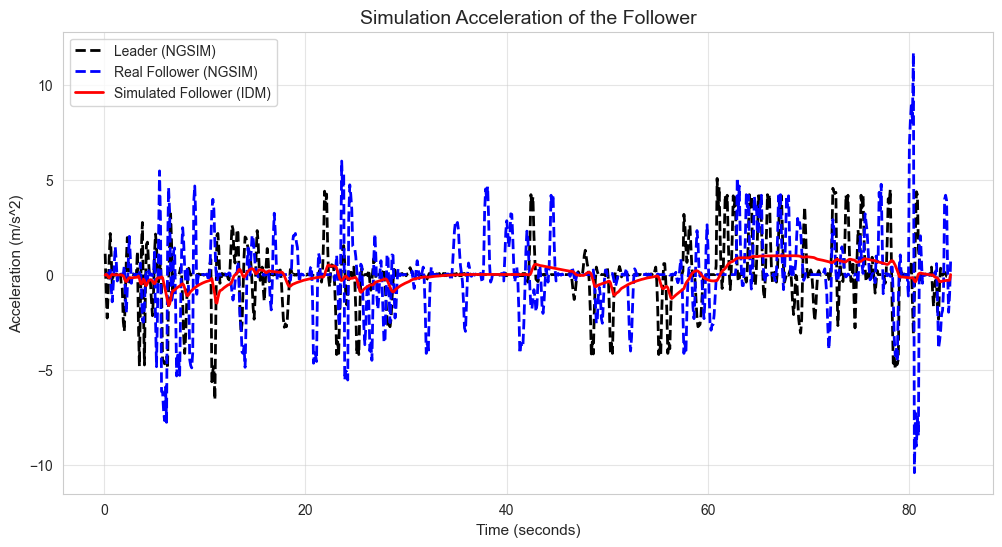

In [12]:
# Plot showing the acceleratiom of the leader, the follower, and the follower simulated in the IDM model
plt.figure(figsize = (12,6))
plt.plot(time_data, leader_acc, 'k--', linewidth = 2, label = 'Leader (NGSIM)')
plt.plot(time_data, data_subset['follower_acc(m/s^2)'].values, 'b--', linewidth = 2, label = 'Real Follower (NGSIM)')
plt.plot(time_data, sim_acc, 'r-', linewidth = 2, label = 'Simulated Follower (IDM)')
plt.xlabel('Time (seconds)', fontsize = 11)
plt.ylabel('Acceleration (m/s^2)', fontsize = 11)
plt.title('Simulation Acceleration of the Follower', fontsize = 14)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()